<a href="https://colab.research.google.com/github/khuranakhurana430-alt/Test/blob/main/Cats_and_Dog(CNN)_Classification_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#                                  FIXED CODES TO RUN THE KAGGLE

!mkdir -p ~/.kaggle
!cp KAGGLE.json ~/.kaggle/
!chmod 600 ~/.kaggle/KAGGLE.json

In [ ]:
#                                DATA DOWNLOADING ( ADD -d)

In [ ]:
!kaggle datasets download -d marquis03/cats-and-dogs

Dataset URL: https://www.kaggle.com/datasets/marquis03/cats-and-dogs
License(s): apache-2.0
100% 9.75M/9.75M [00:01<00:00, 5.39MB/s]



In [ ]:
#                                    FIX CODE TO EXTRACT ZIPFILES

In [ ]:
import zipfile
zip_ref = zipfile.ZipFile('/content/cats-and-dogs.zip', 'r')
zip_ref.extractall('/content')
zip_ref.close()

In [ ]:
#                                    REQUIRED IMPORTS

In [ ]:
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Conv2D,MaxPooling2D,BatchNormalization,Dropout,Flatten
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
#                                   DATA GENRATION USING GENERATORS

In [ ]:
train_ds=tf.keras.utils.image_dataset_from_directory(
    directory='/content/train',
    labels='inferred',
    label_mode='int',
    subset='training',
    validation_split=0.2,
    seed=123,
    batch_size=32,
    image_size=(256,256)
)

val_ds=tf.keras.utils.image_dataset_from_directory(
    directory='/content/val',
    labels='inferred',
    label_mode='int',
    batch_size=32,
    validation_split=0.2,
    seed=123,
    subset='validation',
    image_size=(256,256)
)

Found 275 files belonging to 2 classes.
Using 220 files for training.
Found 70 files belonging to 2 classes.
Using 14 files for validation.


In [ ]:
#                                   MODEL SELECTION AND TUNING

In [ ]:
model=Sequential()

model.add(Conv2D(32,kernel_size=(3,3),padding='same',activation='relu',input_shape=(256,256,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(64,kernel_size=(3,3),padding='same',activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(128,kernel_size=(3,3),padding='same',activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Flatten())
#model.add(GlobalAveragePooling2D)
#model.add(Dropout(0.4))

model.add(Dense(1,activation='sigmoid'))

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 256, 256, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256, 256, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128, 128, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 131072)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │       131,073 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,217 (879.75 KB)

 Trainable params: 224,769 (878.00 KB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
#                                   MODEL COMPILATION

In [ ]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [ ]:
#                                    MODEL TRAINING

In [ ]:
history=model.fit(train_ds,validation_data=val_ds,epochs=10,callbacks=[EarlyStopping(patience=3)])

Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - accuracy: 0.5591 - loss: 6.3851 - val_accuracy: 0.7143 - val_loss: 12.0868
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step - accuracy: 0.7455 - loss: 3.0119 - val_accuracy: 0.7143 - val_loss: 32.3448
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 80ms/step - accuracy: 0.8682 - loss: 1.1843 - val_accuracy: 0.5714 - val_loss: 3.8661
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step - accuracy: 0.8864 - loss: 0.5775 - val_accuracy: 0.7143 - val_loss: 14.8873
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 80ms/step - accuracy: 0.9545 - loss: 0.2191 - val_accuracy: 0.7143 - val_loss: 4.5662
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 80ms/step - accuracy: 0.9409 - loss: 0.3701 - val_accuracy: 0.7143 - val_loss: 4.6114


In [ ]:
#                                    VISUVALIZATION(MATPLOTLIB)

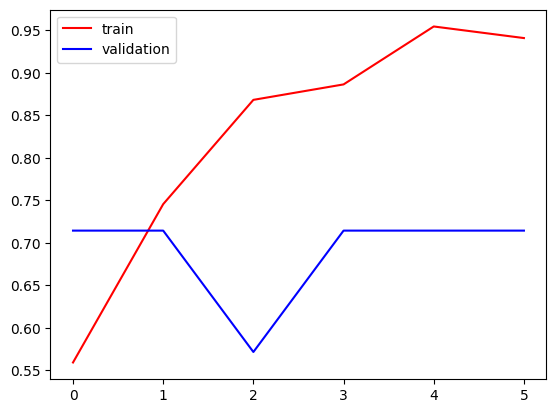

In [ ]:
plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

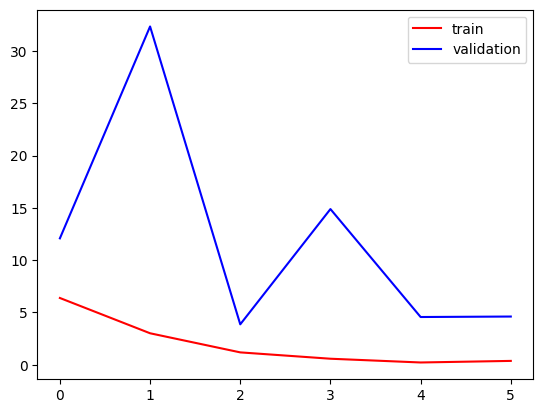

In [ ]:
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()